In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [15]:
import time

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression as SKLinearRegression
from sklearn.metrics import mean_squared_error

from algorithms.linear_models.linear_regression import LinearRegression

In [46]:
X, y = make_regression(
    n_samples=500,
    n_features=5,
    noise=15,
    random_state=42
)

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [48]:
batch = LinearRegression(optimizer="batch")

start = time.perf_counter()

batch.fit(X, y)

batch_time = time.perf_counter() - start

batch_predictions = batch.predict(X)

In [49]:
sgd = LinearRegression(learningrate=0.001,iterations=100,optimizer="sgd")

start = time.perf_counter()

sgd.fit(X, y)

sgd_time = time.perf_counter() - start

sgd_predictions = sgd.predict(X)

In [50]:
mini = LinearRegression(iterations=200,optimizer="mini-batch")

start = time.perf_counter()

mini.fit(X, y)

mini_time = time.perf_counter() - start

mini_predictions = mini.predict(X)

In [52]:
sk = SKLinearRegression()

start = time.perf_counter()

sk.fit(X, y)

sk_time = time.perf_counter() - start

sk_predictions = sk.predict(X)

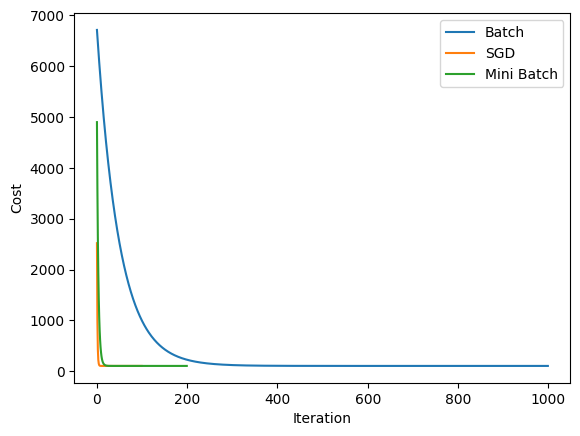

In [56]:
plt.plot(batch.cost_history, label="Batch")
plt.plot(sgd.cost_history, label="SGD")
plt.plot(mini.cost_history, label="Mini Batch")

plt.xlabel("Iteration")
plt.ylabel("Cost")

plt.legend()

plt.show()

In [58]:
print("Batch      :", mean_squared_error(y, batch_predictions))
print("SGD        :", mean_squared_error(y, sgd_predictions))
print("Mini Batch :", mean_squared_error(y, mini_predictions))
print("Scikit     :", mean_squared_error(y, sk_predictions))

Batch      : 208.82474639836843
SGD        : 208.86418754409533
Mini Batch : 208.8273459684638
Scikit     : 208.82470402992016


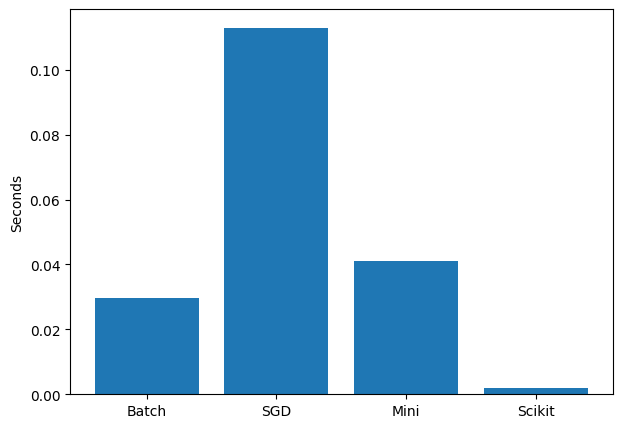

In [59]:
methods = [
    "Batch",
    "SGD",
    "Mini",
    "Scikit"
]

times = [
    batch_time,
    sgd_time,
    mini_time,
    sk_time
]

plt.figure(figsize=(7,5))

plt.bar(methods, times)

plt.ylabel("Seconds")

plt.show()